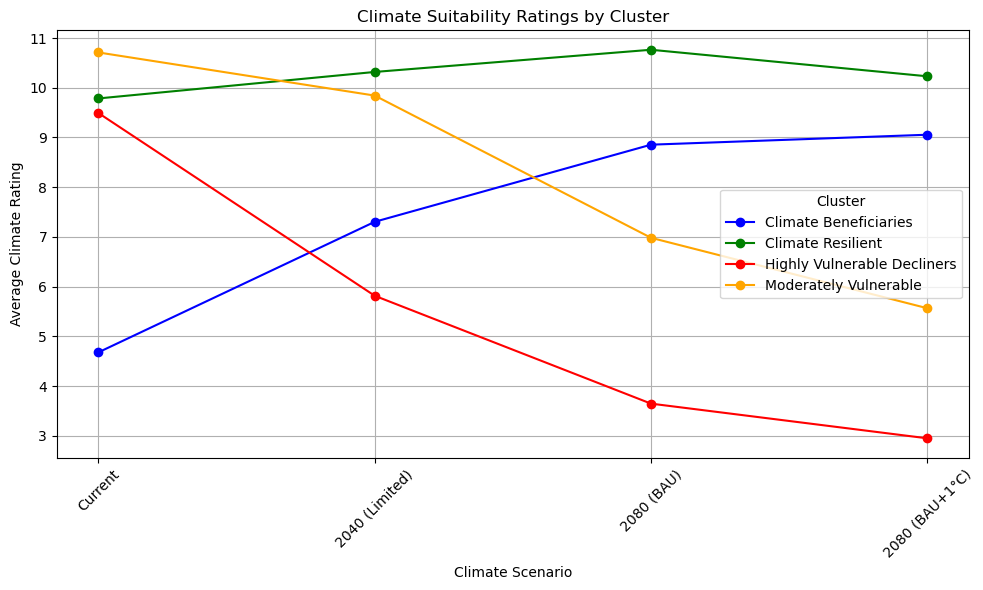

Top 10 genera in Highly Vulnerable Decliners cluster:
Genus
Rhododendron    232
Betula           74
Abies            49
Primula          49
Sempervivum      48
Ribes            41
Acer             39
Saxifraga        38
Veronica         35
Sorbus           32
Name: count, dtype: int64


In [8]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

# Load the data
data = pd.read_csv('data/FullJoin3_with_climate_ratings-proofed.csv')

# Select the relevant columns for clustering
ratings_columns = [
    'climate_rating_current_sheet',
    'climate_rating_emissions_limited_2040',
    'climate_rating_business_as_usual_2080',
    'climate_rating_bau_plus_1degree_2080'
]
ratings_data = data[ratings_columns]

# Impute missing values with the mean
imputer = SimpleImputer(strategy='mean')
imputed_data = imputer.fit_transform(ratings_data)

# Standardize the data
scaler = StandardScaler()
scaled_data = scaler.fit_transform(imputed_data)

# Apply K-means clustering
kmeans = KMeans(n_clusters=4, random_state=42)
data['Cluster'] = kmeans.fit_predict(scaled_data)

# Corrected mapping of clusters to descriptive names
cluster_labels = {
    0: 'Climate Resilient',
    1: 'Moderately Vulnerable',
    2: 'Highly Vulnerable Decliners',
    3: 'Climate Beneficiaries'
}
data['Cluster_Description'] = data['Cluster'].map(cluster_labels)

# Visualize the clusters with custom colors
colors = {
    'Highly Vulnerable Decliners': 'red',
    'Moderately Vulnerable': 'orange',
    'Climate Resilient': 'green',
    'Climate Beneficiaries': 'blue'
}

cluster_means = data.groupby('Cluster_Description')[ratings_columns].mean().T
ax = cluster_means.plot(marker='o', figsize=(10, 6), color=[colors[desc] for desc in cluster_means.columns])

plt.title('Climate Suitability Ratings by Cluster')
plt.xlabel('Climate Scenario')
plt.ylabel('Average Climate Rating')
plt.xticks(ticks=range(len(ratings_columns)), labels=['Current', '2040 (Limited)', '2080 (BAU)', '2080 (BAU+1°C)'], rotation=45)
plt.grid(True)
plt.legend(title='Cluster')
plt.tight_layout()
plt.show()

# Generate nomenclature statistics for Cluster 3 (Highly Vulnerable Decliners)
cluster_3_stats = data[data['Cluster_Description'] == 'Highly Vulnerable Decliners']['Genus'].value_counts().head(10)
print("Top 10 genera in Highly Vulnerable Decliners cluster:")
print(cluster_3_stats)